In [1]:
# Step 1: Load Data

import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/abhishe845/combined-dataset/Combined_dataset.csv")
print("dataset shape :",df.shape)
print("dataset column:",df.columns)

dataset shape : (1000, 24)
dataset column: Index(['product_id', 'title', 'product_description', 'rating', 'ratings_count',
       'initial_price', 'discount', 'final_price', 'currency', 'images',
       'delivery_options', 'product_details', 'breadcrumbs',
       'product_specifications', 'amount_of_stars', 'what_customers_said',
       'seller_name', 'sizes', 'videos', 'seller_information', 'variations',
       'best_offer', 'more_offers', 'category'],
      dtype='object')


In [2]:
#Step 2: Understand Data

print("Data Types:")
print(df.dtypes)

print("\nMissing values: ")
print(df.isnull().sum())

df.info()
df.describe()

Data Types:
product_id                  int64
title                      object
product_description        object
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                object
currency                   object
images                     object
delivery_options           object
product_details            object
breadcrumbs                object
product_specifications     object
amount_of_stars            object
what_customers_said        object
seller_name                object
sizes                      object
videos                     object
seller_information         object
variations                 object
best_offer                 object
more_offers                object
category                   object
dtype: object

Missing values: 
product_id                  0
title                       0
product_description         0
rating                      0
ratings_count       

,product_id,rating,ratings_count,initial_price,discount
count,1.000000e+03,1000.0000,1000.000000,1000.00000,879.000000
mean,1.713437e+07,3.6215,76.691000,2723.24100,53.503982
std,3.813766e+06,1.3744,241.114263,2408.69736,18.029201
min,5.868460e+05,0.0000,0.000000,249.00000,1.000000
25%,1.511501e+07,3.7000,7.000000,1399.00000,44.000000
50%,1.820890e+07,4.1000,17.000000,1999.00000,56.000000
75%,1.902737e+07,4.3000,58.000000,3299.00000,66.000000
max,2.274707e+07,5.0000,4441.000000,22199.00000,88.000000


In [3]:
# Step 3: Data Cleaning

df['final_price']=(df['final_price']
                   .str.replace(',','')
                   .str.replace('₹','')
                   .str.extract(r'(\d+\.?\d*)')
                   .astype(float)
                   .astype(int)
                  )

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col]=df[col].fillna("unknown")


df = df.drop_duplicates()

In [4]:
# Step 4: Feature Engineering

import ast
import numpy as np

df['price_difference'] = df['initial_price'] - df['final_price']

df['popularity_score'] = df['rating'] * np.log1p(df['ratings_count'])

spec_list = ast.literal_eval(df['product_specifications'].iloc[0])
for item in spec_list:
    print(f"{item['specification_name']} : {item['specification_value']}")


Add-Ons : NA
Back : Non-Padded
Compartment Closure : Flap
External Pocket : Zip Pocket
Features : NA
Features 2 : NA
Haul Loop Type : Non-Padded
Laptop Compartment : NA
Laptop Size : NA
Material : Synthetic Leather
Number of External Pockets : 2
Number of Main Compartments : 1
Number of Zips : NA
Occasion : Casual
Padded Shoulder Strap : Non-Padded
Print or Pattern Type : Solid
Shoulder Strap Type : Ergonomic
Side Pockets : NA
Size : Medium
Surface Styling : Tasselled
Tablet Sleeve : NA
Technology : NA
Volume in Litres : Up to 23 Litres
Warranty : NA
Water Resistance : No


In [5]:
#Step 5: Analysis

import pandas as pd

df['final_price'] = pd.to_numeric(df['final_price'], errors='coerce')

#Univariate Analysis

print("UNIVARIATE ANALYSIS :")
print("Numeric Data Summary:\n")
print(df[['rating', 'ratings_count', 'initial_price', 'discount']].describe())
print("\nTop Categories:\n")
print(df['category'].value_counts().head(10))


#Bivariate Analysis

print("\nBIVARIATE ANALYSIS :")
print("Rating vs Final Price:\n")
print(df[['rating', 'final_price']].corr())

print("\nRating vs Ratings Count:\n")
print(df[['rating', 'ratings_count']].corr())


#Category-level Analysis

print("\nCATEGORY LEVEL ANALYSIS :")
print("Average Rating by Category:\n")
print(df.groupby('category')['rating'].mean().sort_values(ascending=False).head(10))
print("\nAverage Price by Category:\n")
print(df.groupby('category')['final_price'].mean().sort_values(ascending=False).head(10))
print("\nTotal Ratings Count by Category:\n")
print(df.groupby('category')['ratings_count'].sum().sort_values(ascending=False).head(10))

UNIVARIATE ANALYSIS :
Numeric Data Summary:

          rating  ratings_count  initial_price
count  1000.0000    1000.000000     1000.00000
mean      3.6215      76.691000     2723.24100
std       1.3744     241.114263     2408.69736
min       0.0000       0.000000      249.00000
25%       3.7000       7.000000     1399.00000
50%       4.1000      17.000000     1999.00000
75%       4.3000      58.000000     3299.00000
max       5.0000    4441.000000    22199.00000

Top Categories:

category
tops            122
dresses         100
shirts           97
jeans            57
sports-shoes     51
tshirts          39
earrings         34
sweaters         34
jackets          29
casual-shoes     23
Name: count, dtype: int64

BIVARIATE ANALYSIS :
Rating vs Final Price:

               rating  final_price
rating       1.000000     0.084587
final_price  0.084587     1.000000

Rating vs Ratings Count:

                 rating  ratings_count
rating         1.000000       0.125795
ratings_count  0.125795

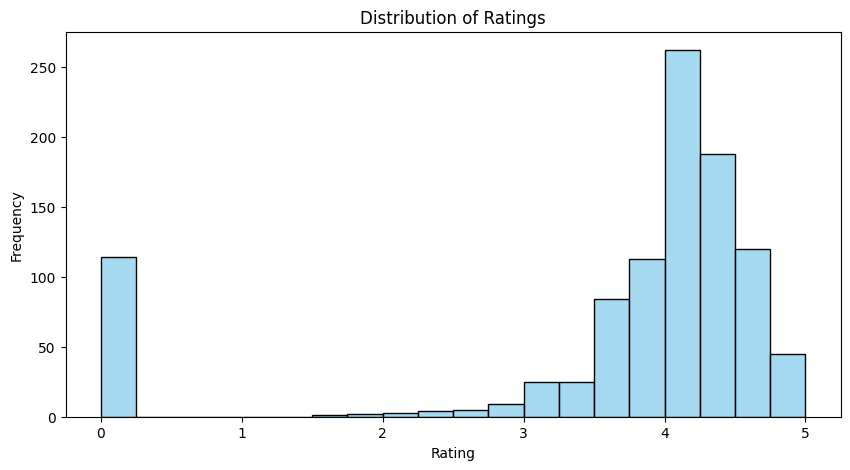

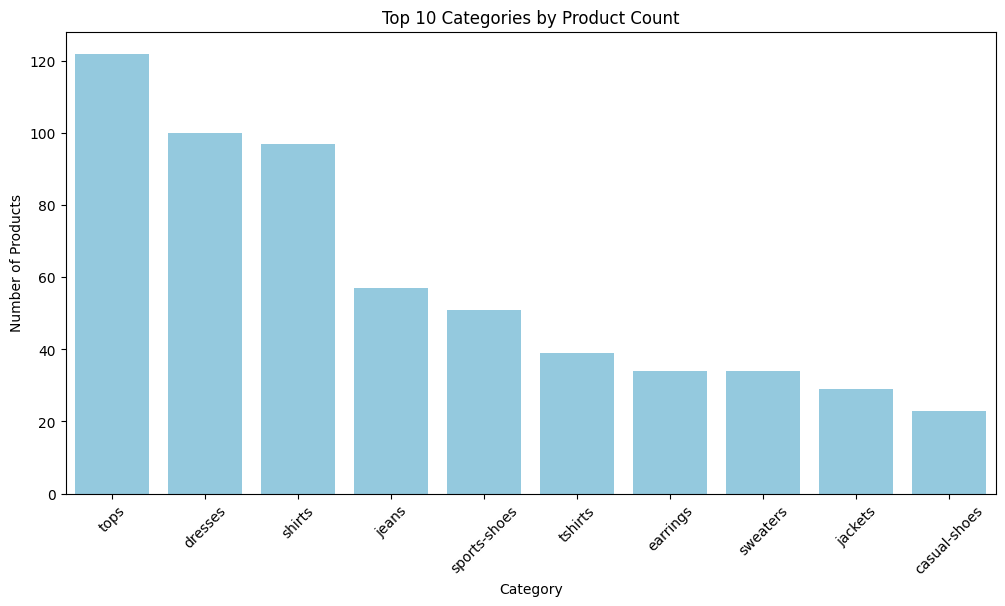

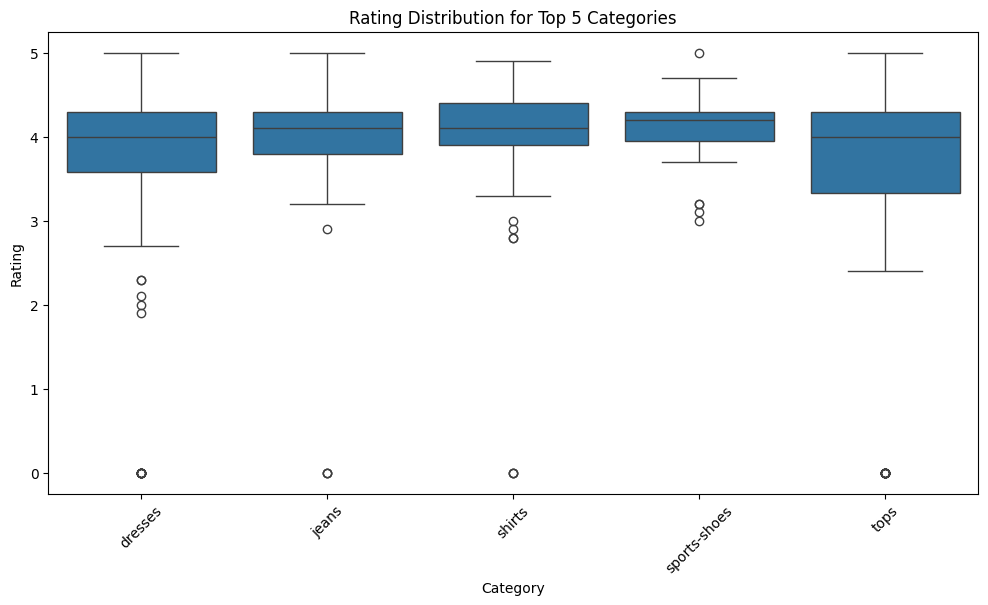

In [6]:
#Step 6: Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Histograms

plt.figure(figsize=(10,5))
sns.histplot(df['rating'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Bar charts

top_categories = df['category'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_categories.index,y=top_categories.values,color='skyblue')
plt.title('Top 10 Categories by Product Count')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

# Boxplots

top5_cat = df['category'].value_counts().head(5).index
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['category'].isin(top5_cat)],x='category',y='rating')
plt.title('Rating Distribution for Top 5 Categories')
plt.xlabel('Category')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.show()

In [ ]:

# Step 7: Insights

"""

Key Findings from the Analysis:

1. Most products have good ratings, indicating overall customer satisfaction.
2. Products with a higher ratings count tend to be more popular and trusted by customers.
3. The relationship between product price and rating is weak, suggesting that higher-priced products are not necessarily rated better.
4. Discounts reduce product prices but do not appear to have a strong impact on customer ratings.
5. Some categories have higher average ratings, prices, and customer engagement than others, indicating stronger market demand.

Business Implications:

1. Businesses should consider both rating and ratings count when evaluating product performance.
2. Customer trust and engagement may be more important than price in determining product success.
3. Discount strategies can be used to drive sales without expecting significant improvements in ratings.
4. High-performing categories should receive greater focus in inventory planning, promotions, and marketing efforts.
5. Customer feedback and review generation should be encouraged to improve product visibility and credibility.

"""

In [ ]:
df.to_csv("cleaned_table.csv", index=False)